# 国内开放式基金当日净值预测原型

这个 Notebook 用一个混合型基金做单基金预测原型，核心思路不是直接预测净值，而是先预测日收益率，再把收益率恢复成净值。

建模思想：
- 基金收益 = 市场 benchmark 收益 + 动态 beta 暴露 + 主动偏离
- 先做最小可用版本，不追求复杂工程化
- 适合学习、调试和后续扩展

In [2]:
# 导入依赖
# 这一格只做环境准备，后面所有数据处理和建模都会用到这些包。

import os
import warnings

import akshare as ak
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# 中文字体优先使用 Linux 环境里更常见的 Noto 字体，避免 SimHei 不存在时刷出 findfont 警告。
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Noto Sans CJK SC",
    "Microsoft YaHei",
    "WenQuanYi Micro Hei",
    "SimHei",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

print("依赖导入完成")

依赖导入完成


In [3]:
# 设置基金代码与实验参数
# 这一步只是把后面要反复用到的变量集中放在一起，便于修改。

fund_code = "002771"
hs300_code = "sh000300"
zz500_code = "sh000905"
cyb_code = "sz399006"
rolling_beta_window = 20
train_ratio = 0.8
random_state = 42

print("基金代码：", fund_code)
print("目标基金类型：混合型-灵活配置")
print("建模思路：benchmark 收益 + 动态 beta + 主动偏离")

基金代码： 002771
目标基金类型：混合型-灵活配置
建模思路：benchmark 收益 + 动态 beta + 主动偏离


In [4]:
# 获取基金基础信息
# 这里先看基金名称、类型、经理、成立时间和业绩比较基准。

fund_basic_info_df = ak.fund_individual_basic_info_xq(symbol=fund_code)
display(fund_basic_info_df)

basic_info_dict = {}
if not fund_basic_info_df.empty and {"item", "value"}.issubset(set(fund_basic_info_df.columns)):
    basic_info_dict = dict(zip(fund_basic_info_df["item"].astype(str), fund_basic_info_df["value"]))

def get_basic_info(key, default="未获取到"):
    return basic_info_dict.get(key, default)

print("基金名称：", get_basic_info("基金名称"))
print("基金类型：", get_basic_info("基金类型"))
print("基金经理：", get_basic_info("基金经理"))
print("成立时间：", get_basic_info("成立时间"))
print("业绩比较基准：", get_basic_info("业绩比较基准"))
print("投资策略：", get_basic_info("投资策略"))
print("投资目标：", get_basic_info("投资目标"))

,item,value
0,基金代码,002771
1,基金名称,安信新回报混合C
2,基金全称,安信新回报灵活配置混合型证券投资基金
3,成立时间,2016-05-09
4,最新规模,1.90亿
5,基金公司,安信基金管理有限责任公司
6,基金经理,陈鹏
7,托管银行,宁波银行股份有限公司
8,基金类型,混合型-灵活配置
9,评级机构,<NA>


基金名称： 安信新回报混合C
基金类型： 混合型-灵活配置
基金经理： 陈鹏
成立时间： 2016-05-09
业绩比较基准： 50%*沪深300指数收益率+50%*中债总指数（全价）收益率
投资策略： 本基金旨在追求绝对回报，注重风险控制，通过严谨的大类资产配置策略和个券精选策略控制下行风险，通过多样化的投资策略实现基金资产稳定增值。
投资目标： 本基金将以严格的风险控制为前提，结合科学严谨、具有前瞻性的宏观策略分析以及深入的个股/个券挖掘，动态灵活调整投资策略，力争为基金份额持有人获取超越业绩比较基准的投资回报。


In [5]:
# 获取基金历史净值
# 这一格获取单位净值、累计净值，并把日期统一成 datetime 再排序。

def normalize_fund_nav_table(raw_df, source_name):
    if raw_df is None or raw_df.empty:
        raise ValueError(f"{source_name} 返回空表，无法继续")

    col_map = {str(c).strip(): c for c in raw_df.columns}

    def pick(*names):
        for name in names:
            if name in col_map:
                return col_map[name]
        return None

    date_col = pick("净值日期", "日期", "date")
    unit_col = pick("单位净值", "累计净值", "nav", "单位净值走势")
    acc_col = pick("累计净值", "acc_nav")
    growth_col = pick("日增长率", "daily_growth_pct", "涨跌幅")
    if date_col is None or unit_col is None:
        raise ValueError(f"{source_name} 缺少必要字段：日期或净值")

    out = pd.DataFrame({
        "date": pd.to_datetime(raw_df[date_col], errors="coerce"),
        "unit_nav": pd.to_numeric(raw_df[unit_col], errors="coerce"),
    })
    if acc_col is not None:
        out["acc_nav"] = pd.to_numeric(raw_df[acc_col], errors="coerce")
    else:
        out["acc_nav"] = out["unit_nav"]
    if growth_col is not None:
        growth_text = raw_df[growth_col].astype(str).str.replace("%", "", regex=False)
        out["daily_growth_pct"] = pd.to_numeric(growth_text, errors="coerce")
    else:
        out["daily_growth_pct"] = out["unit_nav"].pct_change() * 100

    out = out.dropna(subset=["date", "unit_nav"]).sort_values("date").drop_duplicates("date").reset_index(drop=True)
    return out

unit_nav_raw_df = ak.fund_open_fund_info_em(symbol=fund_code, indicator="单位净值走势")
acc_nav_raw_df = ak.fund_open_fund_info_em(symbol=fund_code, indicator="累计净值走势")

unit_nav_df = normalize_fund_nav_table(unit_nav_raw_df, "unit_nav")
acc_nav_df = normalize_fund_nav_table(acc_nav_raw_df, "acc_nav") if acc_nav_raw_df is not None and not acc_nav_raw_df.empty else pd.DataFrame()

if not acc_nav_df.empty and "acc_nav" in acc_nav_df.columns:
    acc_nav_df = acc_nav_df[["date", "acc_nav"]].drop_duplicates("date")
    fund_nav_df = unit_nav_df.merge(acc_nav_df, on="date", how="left", suffixes=("", "_acc"))
    fund_nav_df["acc_nav"] = fund_nav_df["acc_nav_acc"].fillna(fund_nav_df["acc_nav"])
    fund_nav_df = fund_nav_df.drop(columns=["acc_nav_acc"], errors="ignore")
else:
    fund_nav_df = unit_nav_df.copy()

fund_nav_df["acc_nav"] = fund_nav_df["acc_nav"].fillna(fund_nav_df["unit_nav"])

display(fund_nav_df.head())
print("基金净值行数：", len(fund_nav_df))
print("日期范围：", fund_nav_df["date"].min(), "->", fund_nav_df["date"].max())

,date,unit_nav,acc_nav,daily_growth_pct
0,2016-05-09,1.000,1.000,0.0
1,2016-05-13,0.999,0.999,0.0
2,2016-05-20,0.999,0.999,0.0
3,2016-05-27,1.000,1.000,0.0
4,2016-06-03,1.002,1.002,0.0


基金净值行数： 2425
日期范围： 2016-05-09 00:00:00 -> 2026-05-22 00:00:00


In [6]:
# 获取市场指数数据
# 至少获取沪深300、中证500、创业板指，并为每条指数计算日收益率。

def normalize_index_table(raw_df, index_name):
    if raw_df is None or raw_df.empty:
        raise ValueError(f"{index_name} 返回空表")

    col_map = {str(c).strip(): c for c in raw_df.columns}

    def pick(*names):
        for name in names:
            if name in col_map:
                return col_map[name]
        return None

    date_col = pick("date", "日期")
    close_col = pick("close", "收盘")
    if date_col is None or close_col is None:
        raise ValueError(f"{index_name} 缺少必要字段：日期或收盘价")

    out = pd.DataFrame({
        "date": pd.to_datetime(raw_df[date_col], errors="coerce"),
        "close": pd.to_numeric(raw_df[close_col], errors="coerce"),
    }).dropna(subset=["date", "close"]).sort_values("date").drop_duplicates("date").reset_index(drop=True)
    out["ret"] = out["close"].pct_change()
    out["index_name"] = index_name
    return out


def fetch_index_daily(index_code, index_name):
    try:
        raw_df = ak.stock_zh_index_daily(symbol=index_code)
        out = normalize_index_table(raw_df, index_name)
        out["source"] = "akshare"
        return out
    except Exception as exc:
        print(f"{index_name} 的 AkShare 获取失败，尝试本地缓存。原因：{exc}")
        local_path = os.path.join("fund_predictor", "data", "raw", "index", f"{index_code}.csv")
        if not os.path.exists(local_path):
            raise FileNotFoundError(f"本地缓存不存在：{local_path}")
        raw_df = pd.read_csv(local_path)
        out = normalize_index_table(raw_df, index_name)
        out["source"] = "local_cache"
        return out

hs300_df = fetch_index_daily(hs300_code, "hs300")
zz500_df = fetch_index_daily(zz500_code, "zz500")
cyb_df = fetch_index_daily(cyb_code, "cyb")

display(hs300_df.head())
display(zz500_df.head())
display(cyb_df.head())

,date,close,ret,index_name,source
0,2002-01-04,1316.455,NaN,hs300,akshare
1,2002-01-07,1302.084,-0.010916,hs300,akshare
2,2002-01-08,1292.714,-0.007196,hs300,akshare
3,2002-01-09,1272.645,-0.015525,hs300,akshare
4,2002-01-10,1281.261,0.006770,hs300,akshare


,date,close,ret,index_name,source
0,2005-01-04,986.927,NaN,zz500,akshare
1,2005-01-05,1003.633,0.016927,zz500,akshare
2,2005-01-06,994.595,-0.009005,zz500,akshare
3,2005-01-07,997.606,0.003027,zz500,akshare
4,2005-01-10,1006.337,0.008752,zz500,akshare


,date,close,ret,index_name,source
0,2010-06-01,973.233,NaN,cyb,akshare
1,2010-06-02,997.119,0.024543,cyb,akshare
2,2010-06-03,998.394,0.001279,cyb,akshare
3,2010-06-04,1027.681,0.029334,cyb,akshare
4,2010-06-07,1069.468,0.040661,cyb,akshare


In [7]:
# 构建基金收益率
# 这里不直接预测净值，而是先预测收益率，原因是收益率更平稳，也更容易与指数收益对齐。

fund_feature_df = fund_nav_df.copy()
fund_feature_df["fund_return"] = fund_feature_df["unit_nav"].pct_change()
fund_feature_df["fund_return_fallback"] = fund_feature_df["daily_growth_pct"] / 100.0
fund_feature_df["fund_return"] = fund_feature_df["fund_return"].fillna(fund_feature_df["fund_return_fallback"])

display(fund_feature_df[["date", "unit_nav", "acc_nav", "daily_growth_pct", "fund_return"]].head(10))
print("基金收益率缺失比例：", fund_feature_df["fund_return"].isna().mean())

,date,unit_nav,acc_nav,daily_growth_pct,fund_return
0,2016-05-09,1.000,1.000,0.0000,0.000000
1,2016-05-13,0.999,0.999,0.0000,-0.001000
2,2016-05-20,0.999,0.999,0.0000,0.000000
3,2016-05-27,1.000,1.000,0.0000,0.001001
4,2016-06-03,1.002,1.002,0.0000,0.002000
5,2016-06-08,1.003,1.003,0.0000,0.000998
6,2016-06-16,1.004,1.004,0.0000,0.000997
7,2016-06-17,1.005,1.005,0.0996,0.000996
8,2016-06-20,1.006,1.006,0.0995,0.000995
9,2016-06-21,1.006,1.006,0.0000,0.000000


基金收益率缺失比例： 0.0


In [8]:
# rolling beta
# beta 表示基金收益对市场指数收益变化的敏感度。
# 对混合型基金来说，beta 可以近似理解为股票仓位的动态映射。

def calc_rolling_beta(df, y_col, x_col, window=20):
    beta_list = []
    for i in range(len(df)):
        if i < window - 1:
            beta_list.append(np.nan)
            continue
        sample = df.iloc[i - window + 1 : i + 1][[y_col, x_col]].dropna()
        if len(sample) < window:
            beta_list.append(np.nan)
            continue
        x = sample[[x_col]].values
        y = sample[y_col].values
        model = LinearRegression()
        model.fit(x, y)
        beta_list.append(float(model.coef_[0]))
    return pd.Series(beta_list, index=df.index)

beta_base_df = fund_feature_df[["date", "fund_return"]].merge(
    hs300_df[["date", "ret"]].rename(columns={"ret": "hs300_return"}),
    on="date",
    how="inner",
).sort_values("date").reset_index(drop=True)

beta_base_df["rolling_beta_20"] = calc_rolling_beta(
    beta_base_df,
    y_col="fund_return",
    x_col="hs300_return",
    window=rolling_beta_window,
)

display(beta_base_df[["date", "fund_return", "hs300_return", "rolling_beta_20"]].head(30))

,date,fund_return,hs300_return,rolling_beta_20
0,2016-05-09,0.000000,-0.020681,NaN
1,2016-05-13,-0.001000,-0.004920,NaN
2,2016-05-20,0.000000,0.005132,NaN
3,2016-05-27,0.001001,-0.000559,NaN
4,2016-06-03,0.002000,0.007018,NaN
5,2016-06-08,0.000998,-0.004113,NaN
6,2016-06-16,0.000997,-0.006961,NaN
7,2016-06-17,0.000996,0.005067,NaN
8,2016-06-20,0.000995,0.000745,NaN
9,2016-06-21,0.000000,-0.002042,NaN


In [9]:
# 构建训练数据
# 这里把基金收益、指数收益、滚动 beta 和滞后项合并到一张表里。

model_df = fund_feature_df[["date", "unit_nav", "acc_nav", "fund_return"]].copy()
model_df = model_df.merge(hs300_df[["date", "ret"]].rename(columns={"ret": "hs300_return"}), on="date", how="left")
model_df = model_df.merge(zz500_df[["date", "ret"]].rename(columns={"ret": "zz500_return"}), on="date", how="left")
model_df = model_df.merge(cyb_df[["date", "ret"]].rename(columns={"ret": "cyb_return"}), on="date", how="left")
model_df = model_df.merge(beta_base_df[["date", "rolling_beta_20"]], on="date", how="left")

model_df["lag_1"] = model_df["fund_return"].shift(1)
model_df["lag_5"] = model_df["fund_return"].shift(5)
model_df["active_vs_hs300"] = model_df["fund_return"] - model_df["hs300_return"]

print("训练表形状：", model_df.shape)
print("缺失值统计：")
print(model_df[["hs300_return", "zz500_return", "cyb_return", "lag_1", "lag_5", "rolling_beta_20", "fund_return"]].isna().sum())
display(model_df.head(10))

训练表形状： (2425, 11)
缺失值统计：
hs300_return        8
zz500_return        8
cyb_return          8
lag_1               1
lag_5               5
rolling_beta_20    27
fund_return         0
dtype: int64


,date,unit_nav,acc_nav,fund_return,hs300_return,zz500_return,cyb_return,rolling_beta_20,lag_1,lag_5,active_vs_hs300
0,2016-05-09,1.000,1.000,0.000000,-0.020681,-0.036542,-0.035505,NaN,NaN,NaN,0.020681
1,2016-05-13,0.999,0.999,-0.001000,-0.004920,-0.002121,-0.004592,NaN,0.000000,NaN,0.003920
2,2016-05-20,0.999,0.999,0.000000,0.005132,0.011677,0.013693,NaN,-0.001000,NaN,-0.005132
3,2016-05-27,1.000,1.000,0.001001,-0.000559,-0.000835,-0.007729,NaN,0.000000,NaN,0.001560
4,2016-06-03,1.002,1.002,0.002000,0.007018,0.003111,0.007501,NaN,0.001001,NaN,-0.005018
5,2016-06-08,1.003,1.003,0.000998,-0.004113,-0.003553,-0.004636,NaN,0.002000,0.000000,0.005111
6,2016-06-16,1.004,1.004,0.000997,-0.006961,-0.003746,-0.012863,NaN,0.000998,-0.001000,0.007958
7,2016-06-17,1.005,1.005,0.000996,0.005067,0.005687,0.010218,NaN,0.000997,0.000000,-0.004071
8,2016-06-20,1.006,1.006,0.000995,0.000745,0.003571,-0.001536,NaN,0.000996,0.001001,0.000250
9,2016-06-21,1.006,1.006,0.000000,-0.002042,-0.011489,-0.013035,NaN,0.000995,0.002000,0.002042


In [10]:
# 时间顺序划分训练集与测试集
# 时间序列不能随机划分，否则会把未来信息泄漏到过去。

feature_columns = [
    "hs300_return",
    "zz500_return",
    "cyb_return",
    "lag_1",
    "lag_5",
    "rolling_beta_20",
    "active_vs_hs300",
]

target_column = "fund_return"

train_df = model_df.dropna(subset=feature_columns + [target_column]).copy().sort_values("date").reset_index(drop=True)
split_index = int(len(train_df) * train_ratio)

train_data = train_df.iloc[:split_index].copy()
test_data = train_df.iloc[split_index:].copy()

X_train = train_data[feature_columns]
y_train = train_data[target_column]
X_test = test_data[feature_columns]
y_test = test_data[target_column]

print("训练集大小：", X_train.shape, y_train.shape)
print("测试集大小：", X_test.shape, y_test.shape)
print("训练集日期范围：", train_data["date"].min(), "->", train_data["date"].max())
print("测试集日期范围：", test_data["date"].min(), "->", test_data["date"].max())

训练集大小： (1918, 7) (1918,)
测试集大小： (480, 7) (480,)
训练集日期范围： 2016-07-05 00:00:00 -> 2024-05-28 00:00:00
测试集日期范围： 2024-05-29 00:00:00 -> 2026-05-22 00:00:00


In [11]:
# 训练 LightGBM 模型
# 这一格用简单参数训练回归模型，不做复杂调参。

lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=4,
    random_state=random_state,
    n_jobs=-1,
)

lgb_model.fit(X_train, y_train)

print("LightGBM 训练完成")
feature_importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": lgb_model.feature_importances_,
}).sort_values("importance", ascending=False)
display(feature_importance_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023614 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 1918, number of used features: 7
[LightGBM] [Info] Start training from score 0.000447
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,feature,importance
6,active_vs_hs300,674
0,hs300_return,615
2,cyb_return,295
5,rolling_beta_20,116
1,zz500_return,65
3,lag_1,46
4,lag_5,30


MAE： 0.002784
RMSE： 0.006738


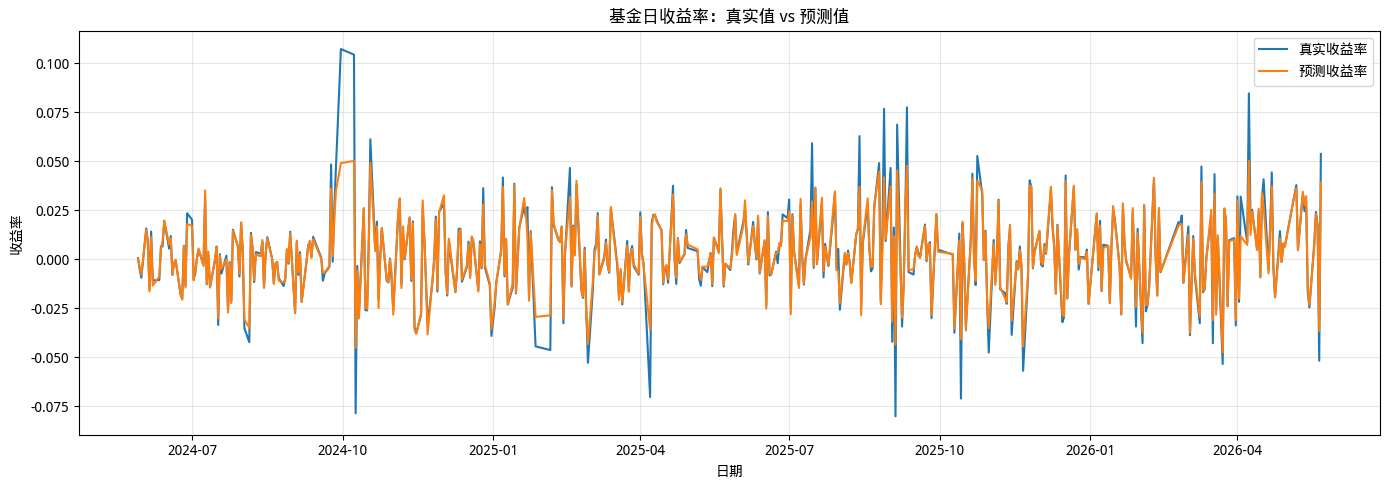

In [12]:
# 预测与评估
# 这一格输出 MAE、RMSE，并画出真实收益率和预测收益率的对比图。

test_data = test_data.copy()
test_data["pred_return"] = lgb_model.predict(X_test)

mae = mean_absolute_error(y_test, test_data["pred_return"])
rmse = np.sqrt(mean_squared_error(y_test, test_data["pred_return"]))

print("MAE：", round(mae, 6))
print("RMSE：", round(rmse, 6))

plt.figure(figsize=(14, 5))
plt.plot(test_data["date"], y_test.values, label="真实收益率", linewidth=1.5)
plt.plot(test_data["date"], test_data["pred_return"], label="预测收益率", linewidth=1.5)
plt.title("基金日收益率：真实值 vs 预测值")
plt.xlabel("日期")
plt.ylabel("收益率")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# 恢复预测净值
# 这一格把前面预测出来的收益率还原成净值，并和真实净值对比。

test_data["last_nav"] = test_data["unit_nav"].shift(1)

for idx in test_data.index:
    if pd.isna(test_data.loc[idx, "last_nav"]):
        current_date = test_data.loc[idx, "date"]
        prev_nav_row = fund_nav_df[fund_nav_df["date"] < current_date].sort_values("date").tail(1)
        if not prev_nav_row.empty:
            test_data.loc[idx, "last_nav"] = float(prev_nav_row["unit_nav"].iloc[0])

test_data["actual_nav"] = test_data["unit_nav"]
test_data["pred_nav"] = test_data["last_nav"] * (1 + test_data["pred_return"])
test_data["nav_error"] = test_data["pred_nav"] - test_data["actual_nav"]
test_data["nav_abs_error"] = test_data["nav_error"].abs()

display(test_data[["date", "last_nav", "actual_nav", "pred_nav", "nav_error", "nav_abs_error"]].head(20))
print("净值预测平均绝对误差：", round(test_data["nav_abs_error"].mean(), 6))

,date,last_nav,actual_nav,pred_nav,nav_error,nav_abs_error
1918,2024-05-29,2.1015,2.1028,2.102441,-0.000359,0.000359
1919,2024-05-30,2.1028,2.0919,2.093772,0.001872,0.001872
1920,2024-05-31,2.0919,2.0722,2.075483,0.003283,0.003283
1921,2024-06-03,2.0722,2.1048,2.103362,-0.001438,0.001438
1922,2024-06-04,2.1048,2.1238,2.121072,-0.002728,0.002728
1923,2024-06-05,2.1238,2.0914,2.088958,-0.002442,0.002442
1924,2024-06-06,2.0914,2.1210,2.115207,-0.005793,0.005793
1925,2024-06-07,2.1210,2.0981,2.092583,-0.005517,0.005517
1926,2024-06-11,2.0981,2.0759,2.079593,0.003693,0.003693
1927,2024-06-12,2.0759,2.0896,2.086213,-0.003387,0.003387


净值预测平均绝对误差： 0.009473


In [2]:
from zai import ZhipuAiClient

api_key = "38206a2d89f646a78418f609bd31908d.w602D6x27cu8Qt5y"

client = ZhipuAiClient(api_key=api_key)

# 定义工具参数
tools = [{
    "type": "web_search",
    "web_search": {
        "enable": "True",
        "search_engine": "search_pro",
        "search_result": "True",
        "search_prompt": "你是一位财经分析师。请用简洁的语言总结网络搜索{search_result}中的关键信息，按重要性排序并引用来源日期。今天的日期是2026年5月24日。",
        "count": "5",
        "search_domain_filter": "www.sohu.com",
        "search_recency_filter": "noLimit",
        "content_size": "high"
    }
}]

# 定义用户消息
messages = [{
    "role": "user",
    "content": "2026年5月的重要财经事件、政策变化和市场数据"
}]

# 调用API获取响应
response = client.chat.completions.create(
    model="glm-4.7-Flash",  # 模型标识符
    messages=messages,  # 用户消息
    tools=tools         # 工具参数
)

# 打印响应结果
response

Completion(model='glm-4.7-Flash', created=1779613001, choices=[CompletionChoice(index=0, finish_reason='stop', message=CompletionMessage(content='基于提供的网络搜索结果，虽然未直接包含2026年5月的具体事件，但以下是基于**2025年底至2026年初**的关键财经动态，作为2026年5月的市场背景与政策参考：\n\n**1. 宏观政策：2026年继续实施更加积极的财政政策**\n*   **内容：** 财政部在2025年12月底的全国财政工作会议上定调，2026年将实施更加积极的财政政策。重点包括扩大财政支出、优化政府债券工具组合、提高转移支付资金效能、强化重点领域保障以及加强财政金融协同。\n*   **来源：** [ref_1] (2025年12月27-28日)\n\n**2. 货币政策：美联储降息预期降温，高盛预测降息两次**\n*   **内容：** 美联储副主席杰斐逊表示当前利率处于合适位置，不急于降息。市场对2026年降息预期从三次缩减至两次。高盛预测美联储将于2026年6月和9月各降息25个基点，并预计美国GDP增速达2.8%。\n*   **来源：** [ref_2], [ref_3] (2026年1月11日)\n\n**3. 外汇市场：美元走弱，亚洲货币迎补涨窗口**\n*   **内容：** 特朗普默许弱势美元，美元指数跌至四年低位。日元受干预疑虑影响剧烈波动，美元/日元一度触及159高位。市场策略师认为，在货币政策分化下，日元、韩元等亚洲货币有望迎来补涨。\n*   **来源：** [ref_4], [ref_5] (2026年1月)\n\n**4. 市场数据：国内ETF规模突破6万亿元**\n*   **内容：** 截至2025年12月27日，国内ETF总规模已突破6万亿元关口，其中股票型ETF占据主导地位。华泰柏瑞沪深300ETF为规模最大的产品。\n*   **来源：** [ref_1] (2025年12月26日)\n\n**5. 产业趋势：商业火箭与机器人产业加速**\n*   **内容：** 上交所发布指引支持商业火箭企业登陆科创板；工信部成立人形机器人与具身智能标准化技术委员会，推动产业

In [5]:
# 格式化输出
print(response.choices[0].message.content)

基于提供的网络搜索结果，虽然未直接包含2026年5月的具体事件，但以下是基于**2025年底至2026年初**的关键财经动态，作为2026年5月的市场背景与政策参考：

**1. 宏观政策：2026年继续实施更加积极的财政政策**
*   **内容：** 财政部在2025年12月底的全国财政工作会议上定调，2026年将实施更加积极的财政政策。重点包括扩大财政支出、优化政府债券工具组合、提高转移支付资金效能、强化重点领域保障以及加强财政金融协同。
*   **来源：** [ref_1] (2025年12月27-28日)

**2. 货币政策：美联储降息预期降温，高盛预测降息两次**
*   **内容：** 美联储副主席杰斐逊表示当前利率处于合适位置，不急于降息。市场对2026年降息预期从三次缩减至两次。高盛预测美联储将于2026年6月和9月各降息25个基点，并预计美国GDP增速达2.8%。
*   **来源：** [ref_2], [ref_3] (2026年1月11日)

**3. 外汇市场：美元走弱，亚洲货币迎补涨窗口**
*   **内容：** 特朗普默许弱势美元，美元指数跌至四年低位。日元受干预疑虑影响剧烈波动，美元/日元一度触及159高位。市场策略师认为，在货币政策分化下，日元、韩元等亚洲货币有望迎来补涨。
*   **来源：** [ref_4], [ref_5] (2026年1月)

**4. 市场数据：国内ETF规模突破6万亿元**
*   **内容：** 截至2025年12月27日，国内ETF总规模已突破6万亿元关口，其中股票型ETF占据主导地位。华泰柏瑞沪深300ETF为规模最大的产品。
*   **来源：** [ref_1] (2025年12月26日)

**5. 产业趋势：商业火箭与机器人产业加速**
*   **内容：** 上交所发布指引支持商业火箭企业登陆科创板；工信部成立人形机器人与具身智能标准化技术委员会，推动产业技术熟化与应用落地。
*   **来源：** [ref_1] (2025年12月26日), [ref_9] (2025年12月26日)
